# Neural Image Codec — Improved
Key upgrades over the original:
- **GDN/IGDN** activations instead of ReLU
- **Wider channels** (128/192) for more capacity
- **Residual blocks** in the synthesis (decoder) path
- **MS-SSIM + L1** perceptual distortion loss
- **compressai** EntropyBottleneck + GaussianConditional for proper rate estimation
- **LR scheduler** (ReduceLROnPlateau)
- **Early stopping** with best-model checkpointing
- **PSNR + RD curve** evaluation vs JPEG

In [2]:
# Install extra deps if needed
# !pip install compressai pytorch-msssim

In [22]:
import os
import math
import io
import random
import struct
import zlib

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
import torchvision.utils as vutils

from compressai.layers import GDN
from compressai.entropy_models import EntropyBottleneck, GaussianConditional
from pytorch_msssim import ms_ssim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

log2 = math.log(2.0)

Using device: cuda


## Dataset

In [23]:
class ImagePathsDataset(Dataset):
    def __init__(self, file_paths, transform=None):
        self.paths = file_paths
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, 0

In [24]:
dataset_root = r"C:\Users\pragnay\OneDrive\Documents\MyProjects\NeuroCodec\data\myPhotos"

all_files = [
    os.path.join(dataset_root, f)
    for f in os.listdir(dataset_root)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
]

if not all_files:
    raise RuntimeError(f"No images found in: {dataset_root}")

print(f"Found {len(all_files)} images.")

random.shuffle(all_files)
val_count  = max(1, int(len(all_files) * 0.1))
val_files  = all_files[:val_count]
train_files = all_files[val_count:]
print(f"Train: {len(train_files)}, Val: {len(val_files)}")

Found 900 images.
Train: 810, Val: 90


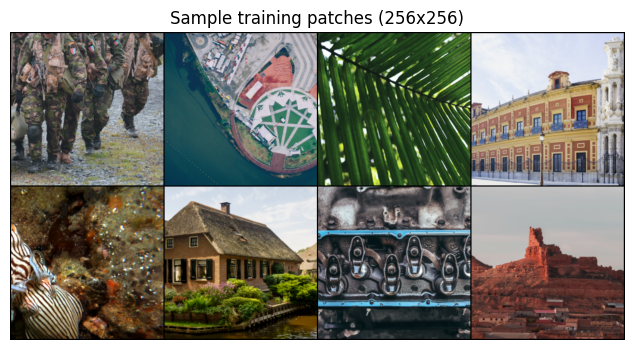

In [49]:
# IMPROVEMENT: larger batch size (RTX 3050 can handle 16-32 at 256x256)
PATCH_SIZE = 256   # bigger patches = richer context for the model
BATCH_SIZE = 16

train_transform = T.Compose([
    T.Resize(320),
    T.RandomCrop(PATCH_SIZE),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.1, 0.1, 0.1, 0.05),
    T.ToTensor(),
])

val_transform = T.Compose([
    T.Resize(320),
    T.CenterCrop(PATCH_SIZE),   # deterministic crop for val
    T.ToTensor(),
])

train_set = ImagePathsDataset(train_files, transform=train_transform)
val_set   = ImagePathsDataset(val_files,   transform=val_transform)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

# Sanity check
x, _ = next(iter(train_loader))
grid = vutils.make_grid(x[:8], nrow=4, normalize=True, value_range=(0,1))
plt.figure(figsize=(8,4))
plt.imshow(np.transpose(grid.numpy(), (1,2,0)))
plt.axis("off")
plt.title(f"Sample training patches ({PATCH_SIZE}x{PATCH_SIZE})")
plt.show()

## Model Architecture

Improvements:
- **GDN/IGDN** instead of ReLU — specifically designed for image statistics
- **Wider channels** (128 main path, 192 latent, 128 hyper) — more representational capacity
- **Residual blocks** in synthesis — better gradient flow, sharper reconstruction
- **EntropyBottleneck** for z, **GaussianConditional** for y — proper learned entropy models

In [39]:
class ResBlock(nn.Module):
    """Residual block for the synthesis transform decoder."""
    def __init__(self, ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ch, ch, 3, padding=1),
        )

    def forward(self, x):
        return x + self.net(x)

In [40]:
# IMPROVEMENT: GDN activations + wider channels
class AnalysisTransform(nn.Module):
    def __init__(self, N=128, M=192):
        super().__init__()
        self.conv1 = nn.Conv2d(3,   N, 5, stride=2, padding=2)
        self.gdn1  = GDN(N)
        self.conv2 = nn.Conv2d(N,   N, 5, stride=2, padding=2)
        self.gdn2  = GDN(N)
        self.conv3 = nn.Conv2d(N,   N, 5, stride=2, padding=2)
        self.gdn3  = GDN(N)
        self.conv4 = nn.Conv2d(N,   M, 5, stride=2, padding=2)  # latent

    def forward(self, x):
        x = self.gdn1(self.conv1(x))
        x = self.gdn2(self.conv2(x))
        x = self.gdn3(self.conv3(x))
        return self.conv4(x)

In [41]:
# IMPROVEMENT: wider hyper path
class HyperAnalysis(nn.Module):
    def __init__(self, M=192, N=128):
        super().__init__()
        self.conv1 = nn.Conv2d(M, N, 3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(N, N, 5, stride=2, padding=2)
        self.conv3 = nn.Conv2d(N, N, 5, stride=2, padding=2)

    def forward(self, y):
        z = F.leaky_relu(self.conv1(y), 0.2)
        z = F.leaky_relu(self.conv2(z), 0.2)
        return self.conv3(z)  # no activation on output

In [42]:
# IMPROVEMENT: outputs mu+sigma for GaussianConditional
class HyperSynthesis(nn.Module):
    def __init__(self, M=192, N=128):
        super().__init__()
        self.tconv1   = nn.ConvTranspose2d(N, N, 5, stride=2, padding=2, output_padding=1)
        self.tconv2   = nn.ConvTranspose2d(N, N, 5, stride=2, padding=2, output_padding=1)
        # Outputs 2*M channels: mu and scale (sigma) for each latent channel
        self.conv_out = nn.Conv2d(N, M * 2, 3, padding=1)

    def forward(self, z_hat):
        h = F.leaky_relu(self.tconv1(z_hat), 0.2)
        h = F.leaky_relu(self.tconv2(h), 0.2)
        h = self.conv_out(h)
        mu, sigma_raw = torch.chunk(h, 2, dim=1)
        sigma = F.softplus(sigma_raw) + 1e-5
        return mu, sigma

In [43]:
# IMPROVEMENT: IGDN activations + residual blocks in decoder
class SynthesisTransform(nn.Module):
    def __init__(self, N=128, M=192):
        super().__init__()
        self.tconv1  = nn.ConvTranspose2d(M, N, 5, stride=2, padding=2, output_padding=1)
        self.igdn1   = GDN(N, inverse=True)
        self.res1    = ResBlock(N)
        self.tconv2  = nn.ConvTranspose2d(N, N, 5, stride=2, padding=2, output_padding=1)
        self.igdn2   = GDN(N, inverse=True)
        self.res2    = ResBlock(N)
        self.tconv3  = nn.ConvTranspose2d(N, N, 5, stride=2, padding=2, output_padding=1)
        self.igdn3   = GDN(N, inverse=True)
        self.tconv4  = nn.ConvTranspose2d(N, 3, 5, stride=2, padding=2, output_padding=1)

    def forward(self, y_hat):
        x = self.igdn1(self.tconv1(y_hat))
        x = self.res1(x)
        x = self.igdn2(self.tconv2(x))
        x = self.res2(x)
        x = self.igdn3(self.tconv3(x))
        x = torch.sigmoid(self.tconv4(x))
        return x

In [44]:
# IMPROVEMENT: proper entropy models from compressai
class NeuralImageCodec(nn.Module):
    def __init__(self, N=128, M=192):
        super().__init__()
        self.N = N
        self.M = M
        self.g_a = AnalysisTransform(N, M)
        self.h_a = HyperAnalysis(M, N)
        self.h_s = HyperSynthesis(M, N)
        self.g_s = SynthesisTransform(N, M)
        # EntropyBottleneck for z (replaces the fixed N(0,1) prior)
        self.entropy_bottleneck = EntropyBottleneck(N)
        # GaussianConditional for y (uses mu/sigma from hyper-synthesis)
        self.gaussian_conditional = GaussianConditional(None)

    def forward(self, x):
        y = self.g_a(x)
        z = self.h_a(y)

        # Quantize z through the entropy bottleneck (handles train/eval correctly)
        z_hat, z_likelihoods = self.entropy_bottleneck(z)

        mu, sigma = self.h_s(z_hat)

        # Quantize y conditioned on (mu, sigma)
        y_hat, y_likelihoods = self.gaussian_conditional(y, sigma, means=mu)

        x_hat = self.g_s(y_hat)

        return x_hat, y_likelihoods, z_likelihoods

    def compress(self, x):
        """For inference: returns quantized reconstructions and likelihoods."""
        y = self.g_a(x)
        z = self.h_a(y)
        z_hat, z_likelihoods = self.entropy_bottleneck(z)
        mu, sigma = self.h_s(z_hat)
        y_hat, y_likelihoods = self.gaussian_conditional(y, sigma, means=mu)
        x_hat = self.g_s(y_hat)
        return x_hat, y_likelihoods, z_likelihoods

In [45]:
model = NeuralImageCodec(N=128, M=192).to(device)
num_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Model parameters: {num_params:.2f} M")

Model parameters: 5.89 M


## Loss Function

Improvements:
- **MS-SSIM** perceptual loss instead of plain L1 — preserves structure/texture better
- **Proper rate** from compressai likelihoods (not the Gaussian log-prob approximation)

In [46]:
def rate_from_likelihoods(likelihoods, num_pixels):
    """bits-per-pixel from compressai likelihood tensors."""
    return torch.sum(-torch.log2(likelihoods)) / num_pixels


def distortion_loss(x, x_hat):
    """
    MS-SSIM + L1 combo.
    MS-SSIM preserves perceptual quality (edges, textures).
    L1 keeps pixel-level accuracy.
    """
    msssim = 1.0 - ms_ssim(x, x_hat, data_range=1.0, size_average=True)
    l1 = torch.mean(torch.abs(x - x_hat))
    return 0.8 * msssim + 0.2 * l1


def psnr(x, x_hat):
    mse = torch.mean((x - x_hat) ** 2)
    return -10.0 * torch.log10(mse + 1e-8)

## Training Loop

Improvements:
- LR scheduler (ReduceLROnPlateau)
- Early stopping with best-model saving
- PSNR tracked alongside loss
- `update()` call for EntropyBottleneck CDFs

In [47]:
def train_one_epoch(model, loader, optimizer, lambda_rd):
    model.train()
    total_loss = total_D = total_R = total_psnr = 0.0
    count = 0

    for x, _ in loader:
        x = x.to(device)
        B, C, H, W = x.shape
        num_pixels = H * W

        x_hat, y_likelihoods, z_likelihoods = model(x)

        R_y = rate_from_likelihoods(y_likelihoods, num_pixels * B)
        R_z = rate_from_likelihoods(z_likelihoods, num_pixels * B)
        R   = R_y + R_z

        D    = distortion_loss(x, x_hat)
        loss = D + lambda_rd * R

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # stability
        optimizer.step()

        with torch.no_grad():
            p = psnr(x, x_hat).item()

        total_loss += loss.item() * B
        total_D    += D.item() * B
        total_R    += R.item() * B
        total_psnr += p * B
        count      += B

    return total_loss/count, total_D/count, total_R/count, total_psnr/count


@torch.no_grad()
def validate_one_epoch(model, loader, lambda_rd):
    model.eval()
    total_loss = total_D = total_R = total_psnr = 0.0
    count = 0

    for x, _ in loader:
        x = x.to(device)
        B, C, H, W = x.shape
        num_pixels = H * W

        x_hat, y_likelihoods, z_likelihoods = model(x)

        R_y = rate_from_likelihoods(y_likelihoods, num_pixels * B)
        R_z = rate_from_likelihoods(z_likelihoods, num_pixels * B)
        R   = R_y + R_z

        D    = distortion_loss(x, x_hat)
        loss = D + lambda_rd * R

        total_loss += loss.item() * B
        total_D    += D.item() * B
        total_R    += R.item() * B
        total_psnr += psnr(x, x_hat).item() * B
        count      += B

    return total_loss/count, total_D/count, total_R/count, total_psnr/count


def save_checkpoint(model, optimizer, epoch, path):
    torch.save({
        "epoch": epoch,
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
    }, path)
    print(f"  Checkpoint saved → {path}")


def load_checkpoint(model, optimizer, path):
    state = torch.load(path, map_location=device)
    model.load_state_dict(state["model"])
    if optimizer:
        optimizer.load_state_dict(state["optimizer"])
    print(f"Loaded checkpoint from {path}, epoch {state['epoch']}")
    return state["epoch"]

In [ ]:
# IMPROVEMENT: tuned lambda + scheduler + early stopping
# lambda_rd controls quality vs compression:
#   lower  (~0.001) → higher compression, lower quality
#   higher (~0.08)  → lower compression, higher quality
# Train separate models at different lambdas to get a full RD curve.
lambda_rd  = 0.02   # good starting point for JPEG-beating quality
num_epochs = 1000
lr         = 1e-4
PATIENCE   = 25

optimizer  = torch.optim.Adam(model.parameters(), lr=lr)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10, verbose=True
)

train_hist = []   # (loss, D, R, PSNR)
val_hist   = []

best_val_loss     = float('inf')
patience_counter  = 0
start_epoch       = 1
resume            = False

if resume and os.path.exists("codec_best.pth"):
    start_epoch = load_checkpoint(model, optimizer, "codec_best.pth") + 1

for epoch in range(start_epoch, num_epochs + 1):
    print(f"\nEpoch {epoch}/{num_epochs}")

    tr_loss, tr_D, tr_R, tr_psnr = train_one_epoch(model, train_loader, optimizer, lambda_rd)
    va_loss, va_D, va_R, va_psnr = validate_one_epoch(model, val_loader, lambda_rd)

    train_hist.append((tr_loss, tr_D, tr_R, tr_psnr))
    val_hist.append((va_loss, va_D, va_R, va_psnr))

    print(f"  Train — Loss: {tr_loss:.4f}  D: {tr_D:.4f}  R: {tr_R:.4f}  PSNR: {tr_psnr:.2f} dB")
    print(f"  Val   — Loss: {va_loss:.4f}  D: {va_D:.4f}  R: {va_R:.4f}  PSNR: {va_psnr:.2f} dB")

    scheduler.step(va_loss)

    # Best-model checkpoint
    if va_loss < best_val_loss:
        best_val_loss    = va_loss
        patience_counter = 0
        save_checkpoint(model, optimizer, epoch, "codec_best.pth")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs).")
            break

    # Update entropy bottleneck CDFs (required by compressai)
    model.entropy_bottleneck.update()

    # Periodic rolling checkpoint
    save_checkpoint(model, optimizer, epoch, "codec_latest.pth")


Epoch 1/1000


## Training Curves

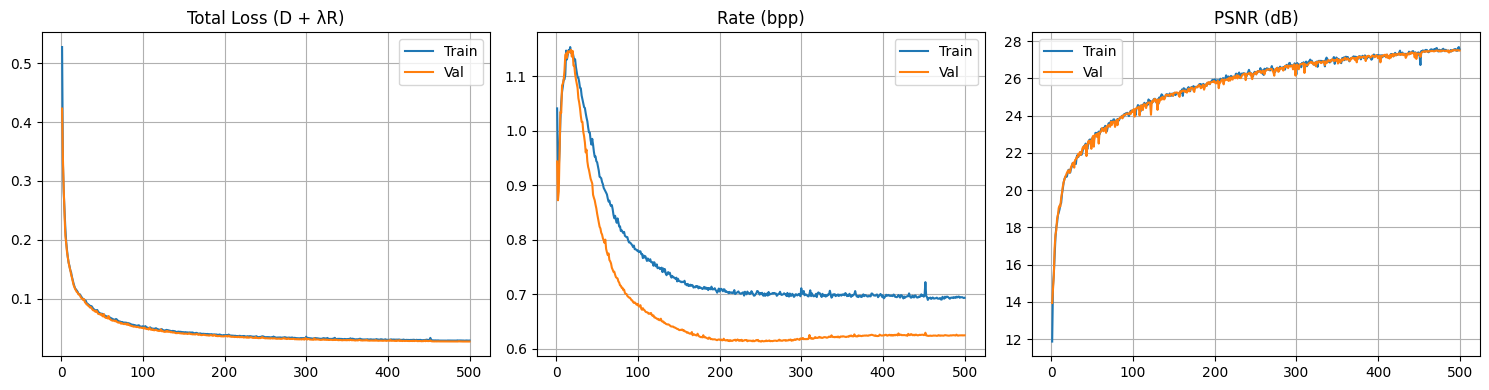

In [18]:
epochs = range(1, len(train_hist) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs, [t[0] for t in train_hist], label="Train")
axes[0].plot(epochs, [v[0] for v in val_hist],   label="Val")
axes[0].set_title("Total Loss (D + λR)")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs, [t[2] for t in train_hist], label="Train")
axes[1].plot(epochs, [v[2] for v in val_hist],   label="Val")
axes[1].set_title("Rate (bpp)")
axes[1].legend(); axes[1].grid(True)

axes[2].plot(epochs, [t[3] for t in train_hist], label="Train")
axes[2].plot(epochs, [v[3] for v in val_hist],   label="Val")
axes[2].set_title("PSNR (dB)")
axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.show()

## Visual Reconstruction Check

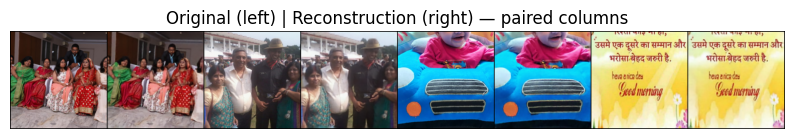

In [19]:
@torch.no_grad()
def show_reconstructions(model, loader, n=4):
    model.eval()
    x, _ = next(iter(loader))
    x = x.to(device)[:n]
    x_hat, _, _ = model(x)
    x     = x.cpu()
    x_hat = x_hat.cpu()

    pairs = []
    for i in range(n):
        pairs.append(x[i])
        pairs.append(x_hat[i])

    grid = vutils.make_grid(pairs, nrow=2*n, normalize=True, value_range=(0,1))
    plt.figure(figsize=(2*n + 2, 4))
    plt.imshow(np.transpose(grid.numpy(), (1,2,0)))
    plt.axis("off")
    plt.title("Original (left) | Reconstruction (right) — paired columns")
    plt.show()

show_reconstructions(model, val_loader, n=4)

## RD Curve vs JPEG

This is the key benchmark: plot PSNR vs bpp for your model and for JPEG at multiple quality levels. Your model should sit **above** the JPEG curve (higher PSNR at the same bpp) to claim a win.

C:\Users\pragnay\AppData\Local\Temp\ipykernel_6140\2988153096.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(path, map_location=device)


Loaded checkpoint from codec_best.pth, epoch 498
Neural codec — bpp: 0.7339, PSNR: 25.41 dB
JPEG Q=10 — bpp: 0.5045, PSNR: 23.95 dB
JPEG Q=20 — bpp: 0.7994, PSNR: 26.33 dB
JPEG Q=30 — bpp: 1.0369, PSNR: 27.73 dB
JPEG Q=40 — bpp: 1.2269, PSNR: 28.75 dB
JPEG Q=50 — bpp: 1.4054, PSNR: 29.59 dB
JPEG Q=60 — bpp: 1.5951, PSNR: 30.43 dB
JPEG Q=70 — bpp: 1.8781, PSNR: 31.58 dB
JPEG Q=75 — bpp: 2.0558, PSNR: 32.31 dB
JPEG Q=80 — bpp: 2.3338, PSNR: 33.30 dB
JPEG Q=85 — bpp: 2.7030, PSNR: 34.57 dB
JPEG Q=90 — bpp: 3.3274, PSNR: 36.37 dB
JPEG Q=95 — bpp: 4.5902, PSNR: 39.20 dB


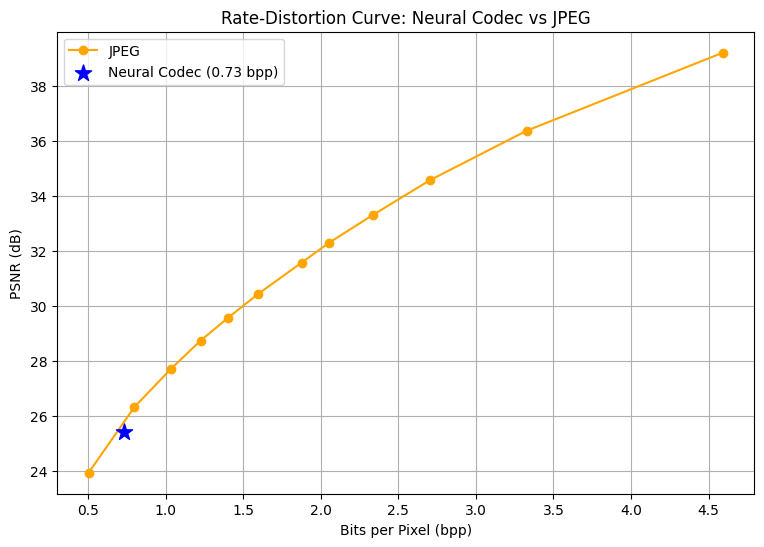


★ If blue star is ABOVE JPEG → you're beating JPEG ★


In [30]:
import os, io
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as T
import torch.nn.functional as F
from PIL import Image


# ---------- PATCH UTILS ----------
def extract_patches(x, patch_size=256, stride=256):
    _, _, H, W = x.shape
    patches, coords = [], []

    for i in range(0, H, stride):
        for j in range(0, W, stride):
            patch = x[:, :, i:i+patch_size, j:j+patch_size]

            pad_h = patch_size - patch.shape[2]
            pad_w = patch_size - patch.shape[3]

            if pad_h > 0 or pad_w > 0:
                patch = F.pad(patch, (0, pad_w, 0, pad_h))

            patches.append(patch)
            coords.append((i, j))

    return patches, coords


def reconstruct_image(outputs, coords, H, W, patch_size=256):
    device = outputs[0].device
    recon = torch.zeros((1, 3, H, W), device=device)
    count = torch.zeros((1, 3, H, W), device=device)

    for out, (i, j) in zip(outputs, coords):
        h, w = out.shape[2], out.shape[3]

        h = min(h, H - i)
        w = min(w, W - j)

        recon[:, :, i:i+h, j:j+w] += out[:, :, :h, :w]
        count[:, :, i:i+h, j:j+w] += 1

    return recon / count


# ---------- NEURAL CODEC ----------
@torch.no_grad()
def evaluate_model_rd_patched(model, img_path, device, patch_size=256, stride=256):
    model.eval()

    img = Image.open(img_path).convert("RGB")
    x = T.ToTensor()(img).unsqueeze(0).to(device)

    _, _, H, W = x.shape
    num_pixels = H * W

    patches, coords = extract_patches(x, patch_size, stride)

    outputs, total_bits = [], 0

    for p in patches:
        x_hat, y_lk, z_lk = model.compress(p)

        outputs.append(x_hat)

        total_bits += (
            torch.sum(-torch.log2(y_lk)) +
            torch.sum(-torch.log2(z_lk))
        )

    x_hat = reconstruct_image(outputs, coords, H, W)

    bpp = total_bits.item() / num_pixels

    mse = torch.mean((x - x_hat) ** 2)
    psnr = -10 * torch.log10(mse + 1e-8)

    return bpp, psnr.item()


# ---------- JPEG ----------
def evaluate_jpeg_rd(img_path, quality):
    img = Image.open(img_path).convert("RGB")
    W, H = img.size
    num_pixels = H * W

    buf = io.BytesIO()
    img.save(buf, format="JPEG", quality=quality)

    bpp = (len(buf.getvalue()) * 8) / num_pixels

    jpeg_img = Image.open(buf).convert("RGB")

    orig = np.array(img).astype(np.float32) / 255.0
    comp = np.array(jpeg_img).astype(np.float32) / 255.0

    mse = np.mean((orig - comp) ** 2)
    psnr = -10 * np.log10(mse + 1e-8)

    return bpp, psnr


# ---------- MAIN ----------
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.cuda.empty_cache()

test_image_path = r"C:\Users\pragnay\OneDrive\Documents\MyProjects\NeuroCodec\kodim01.png"

if os.path.exists(test_image_path):

    if os.path.exists("codec_best.pth"):
        load_checkpoint(model, None, "codec_best.pth")

    model.to(device)

    # 🔥 Patch-based evaluation (OOM-safe)
    neural_bpp, neural_psnr = evaluate_model_rd_patched(
        model,
        test_image_path,
        device,
        patch_size=256,
        stride=256   # change to 128 for overlap
    )

    print(f"Neural codec — bpp: {neural_bpp:.4f}, PSNR: {neural_psnr:.2f} dB")

    jpeg_qualities = [10,20,30,40,50,60,70,75,80,85,90,95]
    jpeg_bpps, jpeg_psnrs = [], []

    for q in jpeg_qualities:
        b, p = evaluate_jpeg_rd(test_image_path, q)
        jpeg_bpps.append(b)
        jpeg_psnrs.append(p)
        print(f"JPEG Q={q:2d} — bpp: {b:.4f}, PSNR: {p:.2f} dB")

    # ---------- PLOT ----------
    plt.figure(figsize=(9, 6))
    plt.plot(jpeg_bpps, jpeg_psnrs, 'o-', label="JPEG", color='orange')

    plt.scatter(
        [neural_bpp], [neural_psnr],
        s=150, marker='*',
        color='blue', zorder=5,
        label=f"Neural Codec ({neural_bpp:.2f} bpp)"
    )

    plt.xlabel("Bits per Pixel (bpp)")
    plt.ylabel("PSNR (dB)")
    plt.title("Rate-Distortion Curve: Neural Codec vs JPEG")
    plt.legend()
    plt.grid(True)
    plt.show()

    print("\n★ If blue star is ABOVE JPEG → you're beating JPEG ★")

else:
    print("Test image not found.")

## Side-by-side: Neural Codec vs JPEG at matched bpp


Neural Codec → bpp: 0.7339, PSNR: 25.41 dB
JPEG (Q=20) → bpp: 0.7994, PSNR: 26.33 dB


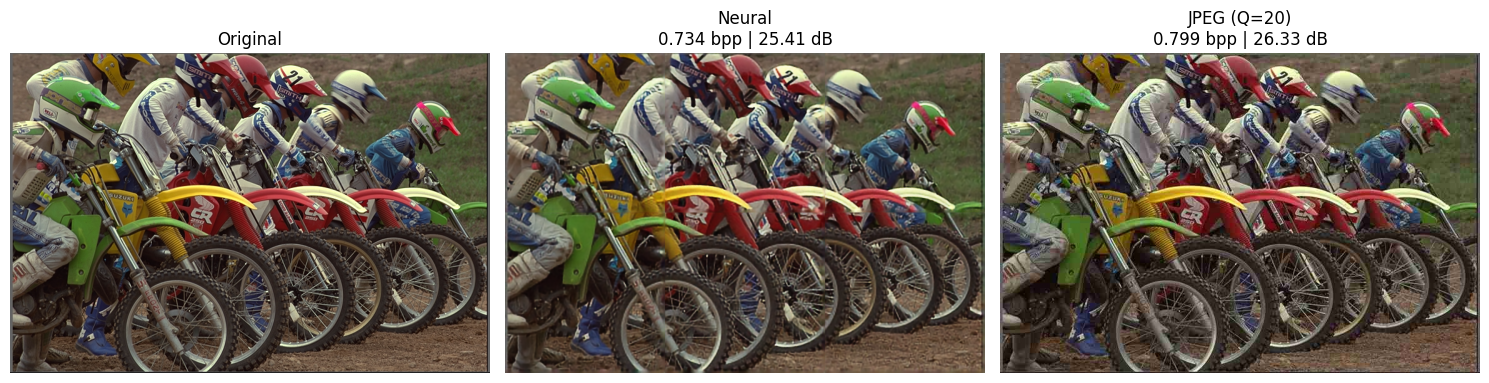

In [33]:
import matplotlib.pyplot as plt


def tensor_to_image(x):
    x = x.squeeze(0).clamp(0, 1).cpu().numpy()
    x = np.transpose(x, (1, 2, 0))
    return x


@torch.no_grad()
def get_neural_reconstruction(model, img_path, device, patch_size=256, stride=256):
    model.eval()

    img = Image.open(img_path).convert("RGB")
    x = T.ToTensor()(img).unsqueeze(0).to(device)

    _, _, H, W = x.shape
    patches, coords = extract_patches(x, patch_size, stride)

    outputs = []
    total_bits = 0

    for p in patches:
        x_hat, y_lk, z_lk = model.compress(p)
        outputs.append(x_hat)

        total_bits += (
            torch.sum(-torch.log2(y_lk)) +
            torch.sum(-torch.log2(z_lk))
        )

    x_hat = reconstruct_image(outputs, coords, H, W)

    bpp = total_bits.item() / (H * W)
    mse = torch.mean((x - x_hat) ** 2)
    psnr = -10 * torch.log10(mse + 1e-8)

    return x, x_hat, bpp, psnr.item()


def get_jpeg_reconstruction(img_path, quality):
    img = Image.open(img_path).convert("RGB")

    buf = io.BytesIO()
    img.save(buf, format="JPEG", quality=quality)

    jpeg_img = Image.open(buf).convert("RGB")

    orig = np.array(img).astype(np.float32) / 255.0
    comp = np.array(jpeg_img).astype(np.float32) / 255.0

    mse = np.mean((orig - comp) ** 2)
    psnr = -10 * np.log10(mse + 1e-8)

    bpp = (len(buf.getvalue()) * 8) / (img.size[0] * img.size[1])

    return img, jpeg_img, bpp, psnr


# ---------- RUN VISUAL COMPARISON ----------

x, x_hat, neural_bpp, neural_psnr = get_neural_reconstruction(
    model, test_image_path, device
)

print(f"\nNeural Codec → bpp: {neural_bpp:.4f}, PSNR: {neural_psnr:.2f} dB")

# Find closest JPEG match in bpp
best_q = None
best_diff = 1e9

for q in range(10, 96, 5):
    _, _, bpp, _ = get_jpeg_reconstruction(test_image_path, q)
    diff = abs(bpp - neural_bpp)
    if diff < best_diff:
        best_diff = diff
        best_q = q

orig_img, jpeg_img, jpeg_bpp, jpeg_psnr = get_jpeg_reconstruction(test_image_path, best_q)

print(f"JPEG (Q={best_q}) → bpp: {jpeg_bpp:.4f}, PSNR: {jpeg_psnr:.2f} dB")


# ---------- SHOW IMAGES ----------
orig_np   = np.array(orig_img) / 255.0
neural_np = tensor_to_image(x_hat)
jpeg_np   = np.array(jpeg_img) / 255.0

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(orig_np)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(neural_np)
plt.title(f"Neural\n{neural_bpp:.3f} bpp | {neural_psnr:.2f} dB")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(jpeg_np)
plt.title(f"JPEG (Q={best_q})\n{jpeg_bpp:.3f} bpp | {jpeg_psnr:.2f} dB")
plt.axis("off")

plt.tight_layout()
plt.show()

Found 24 images
kodim01 (1).png → Neural: 0.6820 bpp | 24.87 dB
kodim02.png → Neural: 0.5299 bpp | 29.51 dB
kodim03.png → Neural: 0.4159 bpp | 31.22 dB
kodim04.png → Neural: 0.5032 bpp | 29.70 dB
kodim05.png → Neural: 0.7339 bpp | 25.41 dB
kodim06.png → Neural: 0.5813 bpp | 26.44 dB
kodim07.png → Neural: 0.4772 bpp | 30.00 dB
kodim08.png → Neural: 0.7012 bpp | 22.70 dB
kodim09.png → Neural: 0.3987 bpp | 29.76 dB
kodim10.png → Neural: 0.4780 bpp | 28.94 dB
kodim11.png → Neural: 0.5640 bpp | 27.69 dB
kodim12.png → Neural: 0.4563 bpp | 29.29 dB
kodim13.png → Neural: 0.7419 bpp | 22.77 dB
kodim14.png → Neural: 0.6728 bpp | 27.49 dB
kodim15.png → Neural: 0.4480 bpp | 29.02 dB
kodim16.png → Neural: 0.4982 bpp | 29.51 dB
kodim17.png → Neural: 0.4860 bpp | 30.18 dB
kodim18.png → Neural: 0.6426 bpp | 26.83 dB
kodim19.png → Neural: 0.5226 bpp | 27.60 dB
kodim20.png → Neural: 0.3643 bpp | 29.00 dB
kodim21.png → Neural: 0.5012 bpp | 27.22 dB
kodim22.png → Neural: 0.5804 bpp | 28.77 dB
kodim23.png 

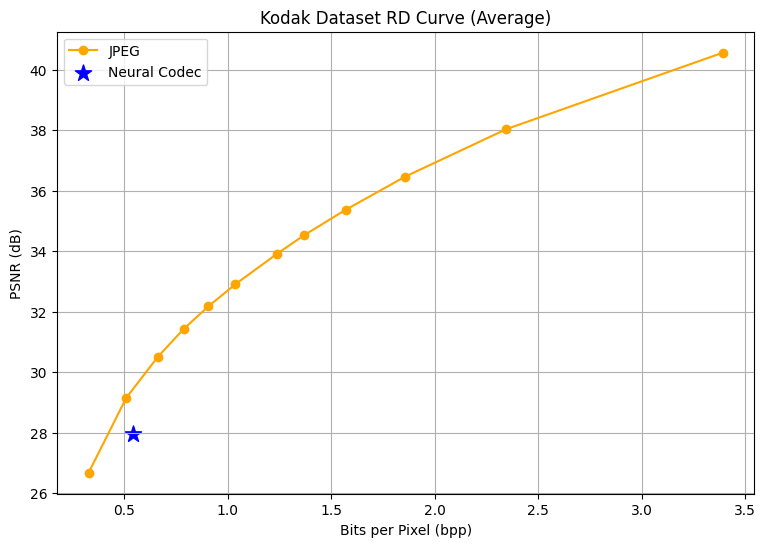


★ If blue point is ABOVE JPEG curve → your model beats JPEG ★


In [35]:
import os
import torch
import matplotlib.pyplot as plt

# 🔥 SET THIS TO YOUR ACTUAL FOLDER
kodak_path = r"C:\Users\pragnay\OneDrive\Documents\MyProjects\NeuroCodec\kodakimgs"   # <-- change if needed

# ---------- VERIFY DATASET ----------
if not os.path.exists(kodak_path):
    raise ValueError(f"Path not found: {kodak_path}")

image_files = sorted([
    f for f in os.listdir(kodak_path)
    if f.lower().endswith(".png")
])

print(f"Found {len(image_files)} images")

if len(image_files) != 24:
    print("⚠️ Warning: Kodak dataset should have 24 images")

# ---------- INIT ----------
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
torch.cuda.empty_cache()

neural_bpps, neural_psnrs = [], []

jpeg_qualities = [10,20,30,40,50,60,70,75,80,85,90,95]
jpeg_results = {q: {"bpp": [], "psnr": []} for q in jpeg_qualities}


# ---------- LOOP ----------
for img_name in image_files:
    img_path = os.path.join(kodak_path, img_name)

    # Neural (patch-based)
    bpp, psnr_val = evaluate_model_rd_patched(
        model,
        img_path,
        device,
        patch_size=256,
        stride=256   # change to 128 for overlap
    )

    neural_bpps.append(bpp)
    neural_psnrs.append(psnr_val)

    print(f"{img_name:10s} → Neural: {bpp:.4f} bpp | {psnr_val:.2f} dB")

    # JPEG
    for q in jpeg_qualities:
        b, p = evaluate_jpeg_rd(img_path, q)
        jpeg_results[q]["bpp"].append(b)
        jpeg_results[q]["psnr"].append(p)


# ---------- AVERAGES ----------
avg_neural_bpp  = sum(neural_bpps) / len(neural_bpps)
avg_neural_psnr = sum(neural_psnrs) / len(neural_psnrs)

print("\n===== FINAL AVERAGE =====")
print(f"Neural Codec → bpp: {avg_neural_bpp:.4f}, PSNR: {avg_neural_psnr:.2f} dB")


jpeg_bpps, jpeg_psnrs = [], []

for q in jpeg_qualities:
    avg_b = sum(jpeg_results[q]["bpp"]) / len(jpeg_results[q]["bpp"])
    avg_p = sum(jpeg_results[q]["psnr"]) / len(jpeg_results[q]["psnr"])

    jpeg_bpps.append(avg_b)
    jpeg_psnrs.append(avg_p)

    print(f"JPEG Q={q:2d} → bpp: {avg_b:.4f}, PSNR: {avg_p:.2f} dB")


# ---------- PLOT RD CURVE ----------
plt.figure(figsize=(9,6))

plt.plot(jpeg_bpps, jpeg_psnrs, 'o-', label="JPEG", color='orange')

plt.scatter(
    [avg_neural_bpp],
    [avg_neural_psnr],
    color='blue',
    s=150,
    marker='*',
    label="Neural Codec"
)

plt.xlabel("Bits per Pixel (bpp)")
plt.ylabel("PSNR (dB)")
plt.title("Kodak Dataset RD Curve (Average)")
plt.legend()
plt.grid(True)
plt.show()


# ---------- FINAL INTERPRETATION ----------
print("\n★ If blue point is ABOVE JPEG curve → your model beats JPEG ★")